<a href="https://colab.research.google.com/github/tasneem1865/Deep-Learning-Lab/blob/main/Practical12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step: 500
Step: 1000
Step: 1500
Step: 2000
Step: 2500
Step: 3000


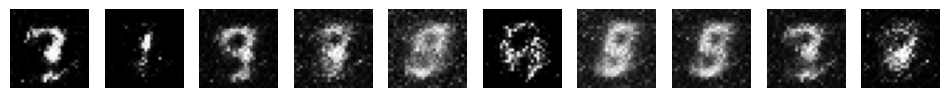

In [ ]:
# GAN for Handwritten Digits
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST Dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images (-1 to 1)
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)

# Generator
generator = tf.keras.Sequential([
    tf.keras.Input(shape=(100,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(784, activation='tanh')
])

# Discriminator
discriminator = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build GAN
discriminator.trainable = False

gan = tf.keras.Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Training
batch_size = 128
steps = 3000

for step in range(steps):

    # Train Discriminator
    discriminator.trainable = True

    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
    discriminator.train_on_batch(fake_images, np.zeros((batch_size, 1)))

    # Train Generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))
    gan.train_on_batch(noise, np.ones((batch_size, 1)))

    if (step + 1) % 500 == 0:
        print("Step:", step + 1)

# Generate Images
noise = np.random.normal(0, 1, (10, 100))
generated_images = generator.predict(noise, verbose=0)

plt.figure(figsize=(12,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()